# Étape 2 – Prétraitement et Extraction de Features (ResNet50)

## Objectif
Extraire des embeddings visuels de 2048 dimensions à partir des 300 images de l'échantillon stratifié (sample_paths.json) grâce à un modèle ResNet50 pré-entraîné gelé.

## Stratégie
- Utiliser PyTorch + torchvision
- Preprocessing standard ImageNet
- Feature extractor (couches convolutionnelles gelées)
- Sauvegarde optimisée pour les étapes 3 et 4

## Définition of Done
- [ ] Notebook structuré avec en-tête
- [ ] 300 images chargées depuis sample_paths.json
- [ ] Preprocessing et Dataset créés
- [ ] Features extraites et sauvegardées (features.npy + metadata)
- [ ] Visualisation exploratoire réalisée

In [1]:
# =============================================================================
# 🧠 BRAINSCANAI — Détection de Tumeurs Cérébrales sur Radiographies
# =============================================================================
# Étape 2 : Prétraitement et Extraction de Features (ResNet50)
# Notebook  : 02_pretraitement_extraction_features.ipynb
# Auteur    : Valentin Trouillez
# Date      : 2026
# =============================================================================

# ── Bibliothèques standard ────────────────────────────────────────────────────
import json
import warnings
from pathlib import Path

# ── Calcul numérique & dataframes ─────────────────────────────────────────────
import numpy as np
import pandas as pd

# ── Deep Learning ─────────────────────────────────────────────────────────────
import torch
import torchvision
import torchvision.transforms as transforms
from torchvision import models

# ── Vision par ordinateur ─────────────────────────────────────────────────────
from PIL import Image

# ── Machine Learning ──────────────────────────────────────────────────────────
from sklearn.decomposition import PCA

# ── Visualisation ─────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns

# ── Progression ───────────────────────────────────────────────────────────────
from tqdm import tqdm

warnings.filterwarnings("ignore")

# =============================================================================
# CONSTANTES DU PROJET
# =============================================================================

SEED         = 42
PROJECT_ROOT = Path("..")   # racine du projet (pour les données brutes)

# Chemins des fichiers d'entrée / sortie
# Note : les outputs sont dans notebook/outputs/ (relatif au dossier notebook/)
#        les données brutes sont à la racine du projet (PROJECT_ROOT)
SAMPLE_PATHS = Path("outputs") / "etape1" / "sample_paths.json"
OUTPUT_DIR   = Path("outputs") / "etape2"
DATA_ROOT    = PROJECT_ROOT / "mri_dataset_brain_cancer_oc"

# Création du dossier de sortie
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Paramètres d'inférence
DEVICE       = "cuda" if torch.cuda.is_available() else "cpu"
BATCH_SIZE   = 32
NUM_WORKERS  = 4

# Reproductibilité
torch.manual_seed(SEED)
np.random.seed(SEED)

# =============================================================================
# AFFICHAGE DES INFORMATIONS D'ENVIRONNEMENT
# =============================================================================

print("=" * 60)
print("🧠  BrainScanAI — Étape 2 : Prétraitement & Features")
print("=" * 60)
print(f"\n⚙️   Constantes initialisées :")
print(f"   SEED          = {SEED}")
print(f"   PROJECT_ROOT  = {PROJECT_ROOT.resolve()}")
print(f"   SAMPLE_PATHS  = {SAMPLE_PATHS.resolve()}")
print(f"   OUTPUT_DIR    = {OUTPUT_DIR.resolve()}")
print(f"   DATA_ROOT     = {DATA_ROOT.resolve()}")
print(f"   BATCH_SIZE    = {BATCH_SIZE}")
print(f"   NUM_WORKERS   = {NUM_WORKERS}")

print(f"\n🖥️   Matériel de calcul :")
print(f"   Device utilisé  : {DEVICE}")
print(f"   CUDA disponible : {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"   Nom GPU         : {torch.cuda.get_device_name(0)}")

# =============================================================================
# CHARGEMENT DU FICHIER sample_paths.json
# =============================================================================

print("\n" + "─" * 60)
print("📂  Chargement de l'échantillon stratifié")
print("─" * 60)

if not SAMPLE_PATHS.exists():
    raise FileNotFoundError(
        f"Fichier introuvable : {SAMPLE_PATHS.resolve()}\n"
        "→ Vérifiez que l'étape 1 (01_exploration_donnees.ipynb) a bien été exécutée."
    )

with open(SAMPLE_PATHS, "r", encoding="utf-8") as f:
    sample_data = json.load(f)

# Comptage par classe
_counts = {}
for record in sample_data:
    _label = record.get("label", "inconnu")
    _counts[_label] = _counts.get(_label, 0) + 1

print(f"\n   ✅  {len(sample_data)} images chargées depuis {SAMPLE_PATHS}")
print(f"\n   📊  Distribution par classe :")
for _lbl, _n in sorted(_counts.items()):
    icon = {"cancer": "🔴", "normal": "🟢", "sans_label": "⚪"}.get(_lbl, "•")
    print(f"        {icon}  {_lbl:<15} : {_n:>4} images  ({_n / len(sample_data) * 100:.1f} %)")

print(f"\n   🔎  5 premières entrées :")
for i, record in enumerate(sample_data[:5]):
    print(f"        [{i}] label={record.get('label', 'n/a'):<12}  path={record.get('path', 'n/a')}")

# =============================================================================
# VALIDATION FINALE
# =============================================================================

print("\n" + "=" * 60)
print("✅  Cellule d'initialisation — Validation")
print("=" * 60)
assert len(sample_data) > 0,       "❌ sample_data est vide"
assert OUTPUT_DIR.exists(),        "❌ OUTPUT_DIR n'a pas été créé"
assert SAMPLE_PATHS.exists(),      "❌ SAMPLE_PATHS est introuvable"
print(f"   ✅  sample_data chargé          : {len(sample_data)} entrées")
print(f"   ✅  OUTPUT_DIR créé             : {OUTPUT_DIR.resolve()}")
print(f"   ✅  Device configuré            : {DEVICE}")
print(f"   ✅  Bibliothèques importées     : torch {torch.__version__}, "
      f"torchvision {torchvision.__version__}, numpy {np.__version__}, "
      f"pandas {pd.__version__}")
print("=" * 60)
print("✅  Prêt pour l'étape 2 — Preprocessing & extraction de features")
print("=" * 60)


🧠  BrainScanAI — Étape 2 : Prétraitement & Features

⚙️   Constantes initialisées :
   SEED          = 42
   PROJECT_ROOT  = /home/valentin/Env_Python/OC_P9
   SAMPLE_PATHS  = /home/valentin/Env_Python/OC_P9/notebook/outputs/etape1/sample_paths.json
   OUTPUT_DIR    = /home/valentin/Env_Python/OC_P9/notebook/outputs/etape2
   DATA_ROOT     = /home/valentin/Env_Python/OC_P9/mri_dataset_brain_cancer_oc
   BATCH_SIZE    = 32
   NUM_WORKERS   = 4

🖥️   Matériel de calcul :
   Device utilisé  : cuda
   CUDA disponible : True
   Nom GPU         : NVIDIA GeForce RTX 4070 SUPER

────────────────────────────────────────────────────────────
📂  Chargement de l'échantillon stratifié
────────────────────────────────────────────────────────────

   ✅  300 images chargées depuis outputs/etape1/sample_paths.json

   📊  Distribution par classe :
        🔴  cancer          :   50 images  (16.7 %)
        🟢  normal          :   50 images  (16.7 %)
        ⚪  sans_label      :  200 images  (66.7 %)

   🔎 

## 2.2 – Preprocessing ImageNet + Custom Dataset PyTorch

### Transformations appliquées

Les images IRM sont redimensionnées et normalisées selon les statistiques ImageNet :

| Transformation | Rôle |
|---|---|
| `Resize(224, 224)` | Aligne la résolution sur l'entrée attendue par ResNet50 |
| `ToTensor()` | Convertit l'image PIL en tenseur `[C, H, W]` avec valeurs dans `[0, 1]` |
| `Normalize(mean, std)` | Recentre chaque canal RGB sur la distribution ImageNet (µ≈0.485, σ≈0.229) |

La normalisation ImageNet est **indispensable** : ResNet50 a été pré-entraîné avec ces statistiques et ses poids internes supposent ces plages de valeurs. Sans elle, les activations seraient décalées et les features extraites moins pertinentes.

### Rôle du Custom Dataset `BrainMRIDataset`

La classe hérite de `torch.utils.data.Dataset` et encapsule trois responsabilités :
1. **Chargement** — ouvre chaque image depuis son chemin absolu et la convertit en RGB.
2. **Encodage du label** — `cancer → 1`, `normal → 0`, inconnu → `-1`.
3. **Conservation du chemin** — chaque `__getitem__` retourne `(image_tensor, label, path)`, ce qui permet de tracer l'origine de chaque feature lors des étapes suivantes.

Le `DataLoader` batche automatiquement les données, parallélise le chargement (`num_workers`) et utilise `pin_memory=True` pour un transfert CPU → GPU plus rapide.

In [2]:
from torch.utils.data import Dataset, DataLoader

# =============================================================================
# TRANSFORMATIONS IMAGENET
# =============================================================================

transform = transforms.Compose([
    transforms.Resize((224, 224)),          # ResNet50 attend du 224×224
    transforms.ToTensor(),                  # PIL → tenseur [C, H, W] en [0,1]
    transforms.Normalize(                   # Normalisation ImageNet
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    ),
])

# =============================================================================
# CUSTOM DATASET
# =============================================================================

class BrainMRIDataset(Dataset):
    """Dataset PyTorch pour les IRM cérébrales.

    Chaque item retourne (image_tensor, label_int, path_str) :
      - label  cancer    → 1
      - label  normal    → 0
      - label  inconnu   → -1
    """

    LABEL_MAP = {"cancer": 1, "normal": 0}

    def __init__(self, data_list, transform=None):
        self.data_list = data_list
        self.transform = transform

    def __len__(self):
        return len(self.data_list)

    def __getitem__(self, idx):
        record = self.data_list[idx]
        path   = record["path"]
        label  = self.LABEL_MAP.get(record.get("label", ""), -1)

        # Chargement de l'image en RGB (gère les IRM en niveaux de gris)
        image = Image.open(path).convert("RGB")

        if self.transform:
            image = self.transform(image)

        return image, label, path

# =============================================================================
# INSTANCIATION DU DATASET ET DU DATALOADER
# =============================================================================

dataset    = BrainMRIDataset(sample_data, transform=transform)
dataloader = DataLoader(
    dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=(DEVICE == "cuda"),   # utile uniquement avec GPU
)

print("=" * 60)
print("📦  Dataset & DataLoader — Validation")
print("=" * 60)
print(f"   ✅  Taille du dataset  : {len(dataset)} images")
print(f"   ✅  Nombre de batchs   : {len(dataloader)}")
print(f"   ✅  Taille d'un batch  : {BATCH_SIZE}")

# =============================================================================
# TEST RAPIDE : premier batch
# =============================================================================

print("\n" + "─" * 60)
print("🔬  Test du premier batch")
print("─" * 60)

images_batch, labels_batch, paths_batch = next(iter(dataloader))

print(f"\n   Forme du tenseur batch  : {images_batch.shape}")
print(f"   dtype                   : {images_batch.dtype}")
print(f"   Plage de valeurs        : [{images_batch.min():.3f}, {images_batch.max():.3f}]")
print(f"\n   Labels (10 premiers)    : {labels_batch[:10].tolist()}")
print(f"\n   Exemple de chemin       : {paths_batch[0]}")

print("\n" + "=" * 60)
print("✅  Preprocessing & Dataset — OK")
print("=" * 60)


📦  Dataset & DataLoader — Validation
   ✅  Taille du dataset  : 300 images
   ✅  Nombre de batchs   : 10
   ✅  Taille d'un batch  : 32

────────────────────────────────────────────────────────────
🔬  Test du premier batch
────────────────────────────────────────────────────────────

   Forme du tenseur batch  : torch.Size([32, 3, 224, 224])
   dtype                   : torch.float32
   Plage de valeurs        : [-2.118, 2.640]

   Labels (10 premiers)    : [-1, -1, 1, 0, 1, -1, -1, -1, 1, -1]

   Exemple de chemin       : /home/valentin/Env_Python/OC_P9/mri_dataset_brain_cancer_oc/sans_label/317c9a6a-1657-4c88-9c01-fb2ea0863b01.jpg

✅  Preprocessing & Dataset — OK


## 2.3 – Chargement du modèle ResNet50 + Feature Extractor

### Pourquoi ResNet50 ?

ResNet50 est un réseau de neurones convolutif pré-entraîné sur ImageNet (1,2 M images, 1 000 classes). Ses couches convolutionnelles ont appris des représentations visuelles très riches (textures, formes, structures) qui se transfèrent bien à d'autres domaines, y compris l'imagerie médicale — c'est le **transfer learning**.

### Ce qu'on fait ici

| Étape | Détail |
|---|---|
| Chargement des poids | `IMAGENET1K_V1` — poids officiels PyTorch pré-entraînés sur ImageNet |
| Suppression de la tête de classification | On retire la dernière couche `fc` (1000 classes) via `nn.Sequential(*list(model.children())[:-1])` |
| Sortie obtenue | Un vecteur de **2048 dimensions** par image (sortie de l'`AvgPool` global) |
| Mode inférence | `.eval()` désactive le dropout et la batchnorm en mode entraînement |
| Transfert GPU | `.to(DEVICE)` envoie les poids sur le GPU si disponible |

Le modèle est entièrement **gelé** : on n'entraîne rien, on utilise uniquement ses poids pour extraire des features.

In [3]:
import torch.nn as nn

# =============================================================================
# CHARGEMENT DU MODÈLE RESNET50 PRÉ-ENTRAÎNÉ
# =============================================================================

print("=" * 60)
print("🏗️   ResNet50 — Chargement et configuration")
print("=" * 60)

# Chargement avec les poids officiels ImageNet
model = models.resnet50(weights="IMAGENET1K_V1")

print(f"\n   ✅  Modèle chargé : ResNet50 (IMAGENET1K_V1)")
print(f"   📐  Nombre de paramètres total : {sum(p.numel() for p in model.parameters()):,}")

# =============================================================================
# CRÉATION DU FEATURE EXTRACTOR
# =============================================================================
# On supprime la dernière couche (fc, Linear(2048 → 1000)) pour conserver
# uniquement les couches convolutionnelles + le GlobalAvgPool.
# La sortie est un tenseur de forme [batch_size, 2048, 1, 1].

feature_extractor = nn.Sequential(*list(model.children())[:-1])

print(f"\n   ✅  Feature extractor créé (couche fc supprimée)")
print(f"   📐  Paramètres du feature extractor : "
      f"{sum(p.numel() for p in feature_extractor.parameters()):,}")

# =============================================================================
# MODE ÉVALUATION + TRANSFERT SUR LE DEVICE
# =============================================================================
# .eval() désactive le dropout et fixe la BatchNorm en mode inférence.
# .to(DEVICE) envoie les poids sur GPU si disponible.

feature_extractor = feature_extractor.eval().to(DEVICE)

print(f"\n   ✅  Modèle en mode .eval()")
print(f"   ✅  Modèle envoyé sur : {DEVICE}")

# =============================================================================
# TEST SUR UN BATCH : vérification de la forme de sortie
# =============================================================================

print("\n" + "─" * 60)
print("🔬  Test d'extraction — premier batch")
print("─" * 60)

# Récupère le premier batch (déjà chargé en mémoire)
images_batch, labels_batch, paths_batch = next(iter(dataloader))

with torch.no_grad():
    # Envoie le batch sur le device
    images_batch_dev = images_batch.to(DEVICE)
    # Extraction des features : shape attendue [batch_size, 2048, 1, 1]
    features_test = feature_extractor(images_batch_dev)

print(f"\n   Forme de sortie brute       : {features_test.shape}")
# Aplatissement → [batch_size, 2048]
features_flat = features_test.squeeze(-1).squeeze(-1)
print(f"   Forme après squeeze         : {features_flat.shape}")
print(f"   dtype                       : {features_flat.dtype}")
print(f"   Device                      : {features_flat.device}")

assert features_flat.shape[0] == BATCH_SIZE,   "❌ La taille du batch ne correspond pas"
assert features_flat.shape[1] == 2048,         "❌ La dimension des features doit être 2048"

print("\n" + "=" * 60)
print("✅  ResNet50 Feature Extractor — OK")
print(f"   → Chaque image produit un vecteur de {features_flat.shape[1]} dimensions")
print("=" * 60)


🏗️   ResNet50 — Chargement et configuration

   ✅  Modèle chargé : ResNet50 (IMAGENET1K_V1)
   📐  Nombre de paramètres total : 25,557,032

   ✅  Feature extractor créé (couche fc supprimée)
   📐  Paramètres du feature extractor : 23,508,032

   ✅  Modèle en mode .eval()
   ✅  Modèle envoyé sur : cuda

────────────────────────────────────────────────────────────
🔬  Test d'extraction — premier batch
────────────────────────────────────────────────────────────

   Forme de sortie brute       : torch.Size([32, 2048, 1, 1])
   Forme après squeeze         : torch.Size([32, 2048])
   dtype                       : torch.float32
   Device                      : cuda:0

✅  ResNet50 Feature Extractor — OK
   → Chaque image produit un vecteur de 2048 dimensions


## 2.4 – Extraction des features en batch

### Ce qu'on fait

On itère sur l'intégralité du `DataLoader` (10 batchs de 32 images ≈ 300 images au total) et on fait passer chaque batch dans le `feature_extractor` (ResNet50 sans la couche `fc`). Pour chaque image, le réseau produit un vecteur de **2 048 dimensions** issu du Global Average Pooling.

### Pourquoi `torch.no_grad()` + `.eval()` ?

| Mécanisme | Rôle |
|---|---|
| `torch.no_grad()` | Désactive le calcul du gradient — inutile en inférence. Divise environ par 2 la consommation mémoire et accélère les calculs. |
| `.eval()` | Fixe les couches `BatchNorm` sur leurs statistiques globales et désactive le `Dropout`. Garantit des features reproductibles et stables. |

### Ce qu'on obtient à la fin

Un tableau NumPy de forme **(300 × 2 048)** : une ligne par image, 2 048 valeurs de features par ligne. Ce tableau sera sauvegardé et utilisé comme point de départ pour les étapes 3 (clustering) et 4 (classification).

In [4]:
import time
from tqdm import tqdm

# =============================================================================
# EXTRACTION DES FEATURES EN BATCH (ResNet50 → 2048 dim)
# =============================================================================

print("=" * 60)
print("🔄  Extraction des features — début")
print("=" * 60)
print(f"   Nombre d'images  : {len(dataset)}")
print(f"   Taille de batch  : {BATCH_SIZE}")
print(f"   Nombre de batchs : {len(dataloader)}")
print(f"   Device           : {DEVICE}")

# ── Stockage intermédiaire ────────────────────────────────────────────────────
all_features = []   # liste de tableaux NumPy (un par batch)
all_labels   = []   # labels correspondants
all_paths    = []   # chemins correspondants

# ── Extraction ────────────────────────────────────────────────────────────────
# torch.no_grad() : désactive le calcul de gradient → moins de mémoire, plus rapide
# feature_extractor est déjà en .eval() et sur DEVICE (cf. cellule 2.3)

t_start = time.perf_counter()

with torch.no_grad():
    for images, labels, paths in tqdm(dataloader, desc="Extraction features"):
        # Transfert sur le device (GPU si disponible, sinon CPU)
        images_dev = images.to(DEVICE)

        # Propagation avant → sortie shape [batch_size, 2048, 1, 1]
        features_out = feature_extractor(images_dev)

        # Aplatissement : [batch_size, 2048, 1, 1] → [batch_size, 2048]
        features_out = features_out.squeeze(2).squeeze(2)

        # Conversion en NumPy (CPU) et stockage
        all_features.append(features_out.cpu().numpy())
        all_labels.append(labels.numpy())
        all_paths.extend(paths)

t_elapsed = time.perf_counter() - t_start

# =============================================================================
# CONCATÉNATION DES BATCHS
# =============================================================================

features_array = np.concatenate(all_features, axis=0)   # (300, 2048)
labels_array   = np.concatenate(all_labels,   axis=0)   # (300,)

# =============================================================================
# VALIDATION
# =============================================================================

print(f"\n   ✅  Extraction terminée en {t_elapsed:.2f} s")
print(f"\n   Forme de features_array : {features_array.shape}")
print(f"   dtype                   : {features_array.dtype}")
print(f"   Forme de labels_array   : {labels_array.shape}")
print(f"   Nombre de chemins       : {len(all_paths)}")

assert features_array.shape == (len(dataset), 2048), \
    f"❌ Forme inattendue : {features_array.shape}, attendu ({len(dataset)}, 2048)"
assert labels_array.shape[0] == len(dataset), \
    f"❌ Nombre de labels incorrect : {labels_array.shape[0]}"
assert len(all_paths) == len(dataset), \
    f"❌ Nombre de chemins incorrect : {len(all_paths)}"

print(f"\n" + "=" * 60)
print("✅  Features extraites — Validation")
print("=" * 60)
print(f"   ✅  features_array : {features_array.shape}  ({features_array.dtype})")
print(f"   ✅  labels_array   : {labels_array.shape}")
print(f"   ✅  {len(all_paths)} chemins conservés")
print(f"   ✅  Temps d'exécution : {t_elapsed:.2f} s")
print("=" * 60)


🔄  Extraction des features — début
   Nombre d'images  : 300
   Taille de batch  : 32
   Nombre de batchs : 10
   Device           : cuda


Extraction features: 100%|██████████| 10/10 [00:00<00:00, 18.02it/s]


   ✅  Extraction terminée en 0.56 s

   Forme de features_array : (300, 2048)
   dtype                   : float32
   Forme de labels_array   : (300,)
   Nombre de chemins       : 300

✅  Features extraites — Validation
   ✅  features_array : (300, 2048)  (float32)
   ✅  labels_array   : (300,)
   ✅  300 chemins conservés
   ✅  Temps d'exécution : 0.56 s


## 2.5 – Sauvegarde des features et metadata

### Pourquoi sauvegarder ?

Les features extraites par ResNet50 sont coûteuses à recalculer (passage de 300 images dans le réseau). On les persiste sous deux formats complémentaires :

| Fichier | Format | Contenu |
|---|---|---|
| `features.npy` | NumPy binaire | Tableau `(300, 2048)` — features brutes, rechargeable en une ligne |
| `metadata.csv` | CSV | Chemin, label numérique et nom de classe pour chaque image |

Ces deux fichiers constituent le **point d'entrée des étapes 3 (clustering) et 4 (classification)** : ils évitent de relancer l'inférence ResNet50 à chaque expérimentation.

In [5]:
# =============================================================================
# SAUVEGARDE DES FEATURES ET METADATA
# =============================================================================

# ── Création du répertoire de sortie ─────────────────────────────────────────
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# ── Sauvegarde du tableau de features ────────────────────────────────────────
features_path = OUTPUT_DIR / "features.npy"
np.save(features_path, features_array)

# ── Construction du DataFrame metadata ───────────────────────────────────────
# Correspondance label entier → nom de classe
LABEL_NAMES = {1: "cancer", 0: "normal", -1: "inconnu"}

metadata = pd.DataFrame({
    "path":       all_paths,
    "label":      labels_array.tolist(),
    "label_name": [LABEL_NAMES.get(int(l), "inconnu") for l in labels_array],
})

# ── Sauvegarde du CSV metadata ────────────────────────────────────────────────
metadata_path = OUTPUT_DIR / "metadata.csv"
metadata.to_csv(metadata_path, index=False)

# =============================================================================
# VALIDATION
# =============================================================================

print("=" * 60)
print("💾  Sauvegarde — Validation")
print("=" * 60)

# Formes et types des tableaux sauvegardés
print(f"\n   📐  features_array   : {features_array.shape}  ({features_array.dtype})")
print(f"   📐  labels_array     : {labels_array.shape}")
print(f"   📐  metadata         : {metadata.shape}  — colonnes : {list(metadata.columns)}")

# Chemins des fichiers créés
print(f"\n   ✅  features.npy  → {features_path.resolve()}")
print(f"   ✅  metadata.csv  → {metadata_path.resolve()}")

# Vérification que les fichiers existent bien sur le disque
assert features_path.exists(), "❌ features.npy introuvable après sauvegarde"
assert metadata_path.exists(), "❌ metadata.csv introuvable après sauvegarde"

# Premiers chemins conservés
print(f"\n   🔎  5 premiers chemins :")
for i, p in enumerate(metadata["path"].head(5)):
    print(f"        [{i}] {p}")

# Distribution des labels
print(f"\n   📊  Distribution des labels :")
dist = metadata["label_name"].value_counts()
for lbl, count in dist.items():
    icon = {"cancer": "🔴", "normal": "🟢", "inconnu": "⚪"}.get(lbl, "•")
    print(f"        {icon}  {lbl:<10} : {count:>4} images  ({count / len(metadata) * 100:.1f} %)")

print(f"\n   ✅  Taille du fichier features.npy : {features_path.stat().st_size / 1024:.1f} Ko")
print(f"   ✅  Taille du fichier metadata.csv  : {metadata_path.stat().st_size / 1024:.1f} Ko")

print("\n" + "=" * 60)
print("✅  Sauvegarde terminée — Prêt pour les étapes 3 & 4")
print("=" * 60)


💾  Sauvegarde — Validation

   📐  features_array   : (300, 2048)  (float32)
   📐  labels_array     : (300,)
   📐  metadata         : (300, 3)  — colonnes : ['path', 'label', 'label_name']

   ✅  features.npy  → /home/valentin/Env_Python/OC_P9/notebook/outputs/etape2/features.npy
   ✅  metadata.csv  → /home/valentin/Env_Python/OC_P9/notebook/outputs/etape2/metadata.csv

   🔎  5 premiers chemins :
        [0] /home/valentin/Env_Python/OC_P9/mri_dataset_brain_cancer_oc/sans_label/317c9a6a-1657-4c88-9c01-fb2ea0863b01.jpg
        [1] /home/valentin/Env_Python/OC_P9/mri_dataset_brain_cancer_oc/sans_label/3a1ca119-8f2b-4337-9df5-89dfc23dc9e4.jpg
        [2] /home/valentin/Env_Python/OC_P9/mri_dataset_brain_cancer_oc/avec_labels/cancer/c6c3d533-e366-42ff-9e69-fa2823910709.jpg
        [3] /home/valentin/Env_Python/OC_P9/mri_dataset_brain_cancer_oc/avec_labels/normal/b8a6c84a-b258-475d-b97d-7612bad79cad.jpg
        [4] /home/valentin/Env_Python/OC_P9/mri_dataset_brain_cancer_oc/avec_labels/cance

## 2.6 – Visualisation exploratoire : PCA 2D des features

### Rôle de la PCA

La **PCA** (Analyse en Composantes Principales) est une technique de réduction de dimension linéaire. Elle projette les 2 048 dimensions extraites par ResNet50 vers un espace à 2 dimensions en maximisant la variance expliquée. Cette projection est purement exploratoire : elle ne sert pas à entraîner un modèle, mais à **visualiser la structure des données** dans un plan lisible.

Les features sont d'abord **standardisées** (moyenne 0, écart-type 1 par dimension) via `StandardScaler` afin que toutes les dimensions contribuent équitablement à la PCA — sans quoi les dimensions à grande variance domineraient la projection.

### Ce qu'on espère voir

Si ResNet50 a extrait des représentations discriminantes, les images **cancer** et **normal** devraient former des nuages de points **distincts et séparables** dans l'espace PC1 / PC2. Une séparation nette confirme que les features brutes sont suffisamment informatives pour alimenter un classificateur à l'étape 4.

À l'inverse, un nuage unique et mélangé indiquerait que la PCA seule ne suffit pas et que les étapes suivantes (clustering, classification supervisée) devront travailler dans l'espace complet à 2 048 dimensions.

📊  PCA 2D — Visualisation exploratoire des features

   ✅  features.npy chargé  : (300, 2048)  (float32)
   ✅  metadata.csv chargé  : (300, 3)

   ✅  Standardisation : µ≈0.0000, σ≈1.0000

   ✅  PCA appliquée
   📐  Variance expliquée — PC1 : 11.6 %  |  PC2 : 6.2 %
   📐  Variance cumulée         : 17.9 %

   ✅  DataFrame PCA construit : (300, 3)
   📊  Distribution :
        ⚪  inconnu    :  200 points
        🔴  cancer     :   50 points
        🟢  normal     :   50 points

   ✅  Graphique sauvegardé → /home/valentin/Env_Python/OC_P9/notebook/outputs/etape2/pca_2d_features.png


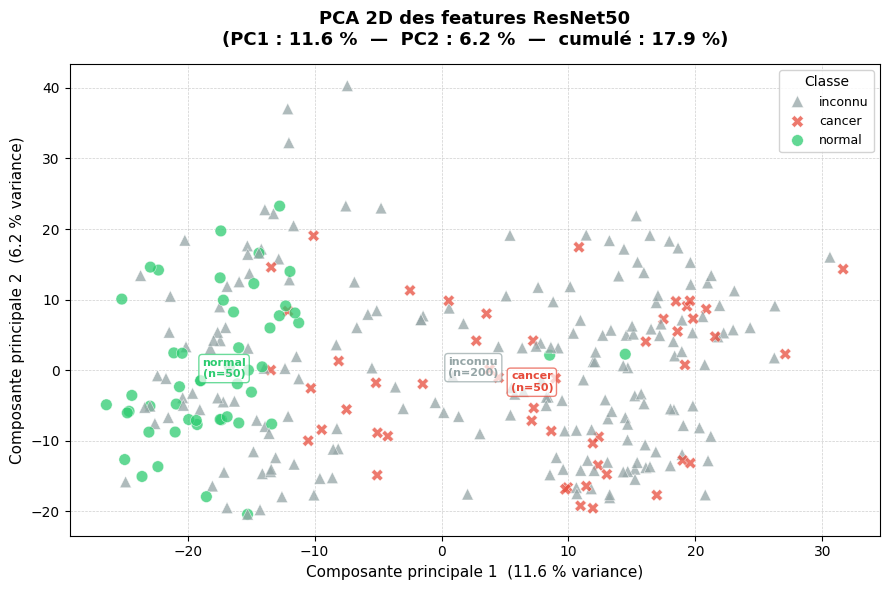


✅  Visualisation PCA 2D — OK


In [6]:
from sklearn.preprocessing import StandardScaler

# =============================================================================
# VISUALISATION EXPLORATOIRE — PCA 2D DES FEATURES
# =============================================================================

print("=" * 60)
print("📊  PCA 2D — Visualisation exploratoire des features")
print("=" * 60)

# =============================================================================
# 1. CHARGEMENT DES DONNÉES DEPUIS OUTPUT_DIR
# =============================================================================

features_path_pca = OUTPUT_DIR / "features.npy"
metadata_path_pca = OUTPUT_DIR / "metadata.csv"

assert features_path_pca.exists(), f"❌ features.npy introuvable : {features_path_pca.resolve()}"
assert metadata_path_pca.exists(), f"❌ metadata.csv introuvable : {metadata_path_pca.resolve()}"

X = np.load(features_path_pca)          # (300, 2048)
df_meta = pd.read_csv(metadata_path_pca)

print(f"\n   ✅  features.npy chargé  : {X.shape}  ({X.dtype})")
print(f"   ✅  metadata.csv chargé  : {df_meta.shape}")

# =============================================================================
# 2. STANDARDISATION DES FEATURES
# =============================================================================
# Chaque dimension est ramenée à (µ=0, σ=1) afin que toutes contribuent
# équitablement à la PCA — sans quoi les dimensions à grande variance dominent.

scaler   = StandardScaler()
X_scaled = scaler.fit_transform(X)      # (300, 2048), float64

print(f"\n   ✅  Standardisation : µ≈{X_scaled.mean():.4f}, σ≈{X_scaled.std():.4f}")

# =============================================================================
# 3. RÉDUCTION DE DIMENSION — PCA(n_components=2)
# =============================================================================

pca        = PCA(n_components=2, random_state=SEED)
X_pca      = pca.fit_transform(X_scaled)   # (300, 2)

var_exp    = pca.explained_variance_ratio_
print(f"\n   ✅  PCA appliquée")
print(f"   📐  Variance expliquée — PC1 : {var_exp[0]*100:.1f} %  |  PC2 : {var_exp[1]*100:.1f} %")
print(f"   📐  Variance cumulée         : {sum(var_exp)*100:.1f} %")

# =============================================================================
# 4. CONSTRUCTION DU DATAFRAME DE VISUALISATION
# =============================================================================

df_pca = pd.DataFrame({
    "PC1":        X_pca[:, 0],
    "PC2":        X_pca[:, 1],
    "label_name": df_meta["label_name"].values,
})

print(f"\n   ✅  DataFrame PCA construit : {df_pca.shape}")
print(f"   📊  Distribution :")
for lbl, cnt in df_pca["label_name"].value_counts().items():
    icon = {"cancer": "🔴", "normal": "🟢", "inconnu": "⚪"}.get(lbl, "•")
    print(f"        {icon}  {lbl:<10} : {cnt:>4} points")

# =============================================================================
# 5. SCATTERPLOT SEABORN
# =============================================================================

PALETTE = {"cancer": "#e74c3c", "normal": "#2ecc71", "inconnu": "#95a5a6"}
MARKERS = {"cancer": "X",       "normal": "o",        "inconnu": "^"}

fig, ax = plt.subplots(figsize=(9, 6))

sns.scatterplot(
    data=df_pca,
    x="PC1",
    y="PC2",
    hue="label_name",
    style="label_name",
    palette=PALETTE,
    markers=MARKERS,
    s=70,
    alpha=0.75,
    edgecolors="white",
    linewidth=0.4,
    ax=ax,
)

# ── Titre et axes ─────────────────────────────────────────────────────────────
ax.set_title(
    "PCA 2D des features ResNet50\n"
    f"(PC1 : {var_exp[0]*100:.1f} %  —  PC2 : {var_exp[1]*100:.1f} %  —  "
    f"cumulé : {sum(var_exp)*100:.1f} %)",
    fontsize=13,
    fontweight="bold",
    pad=14,
)
ax.set_xlabel(f"Composante principale 1  ({var_exp[0]*100:.1f} % variance)", fontsize=11)
ax.set_ylabel(f"Composante principale 2  ({var_exp[1]*100:.1f} % variance)", fontsize=11)

# ── Grille ────────────────────────────────────────────────────────────────────
ax.grid(True, linestyle="--", linewidth=0.5, alpha=0.6)
ax.set_axisbelow(True)

# ── Légende ───────────────────────────────────────────────────────────────────
ax.legend(
    title="Classe",
    title_fontsize=10,
    fontsize=9,
    loc="best",
    framealpha=0.85,
)

# ── Annotation du nombre de points par classe ─────────────────────────────────
for lbl, grp in df_pca.groupby("label_name"):
    cx, cy = grp["PC1"].mean(), grp["PC2"].mean()
    ax.annotate(
        f"{lbl}\n(n={len(grp)})",
        xy=(cx, cy),
        fontsize=8,
        color=PALETTE.get(lbl, "black"),
        fontweight="bold",
        ha="center",
        va="center",
        bbox=dict(boxstyle="round,pad=0.3", fc="white", ec=PALETTE.get(lbl, "grey"), alpha=0.7),
    )

plt.tight_layout()

# =============================================================================
# 6. SAUVEGARDE DU GRAPHIQUE
# =============================================================================

pca_plot_path = OUTPUT_DIR / "pca_2d_features.png"
fig.savefig(pca_plot_path, dpi=150, bbox_inches="tight")

print(f"\n   ✅  Graphique sauvegardé → {pca_plot_path.resolve()}")
assert pca_plot_path.exists(), "❌ pca_2d_features.png introuvable après sauvegarde"

plt.show()

print("\n" + "=" * 60)
print("✅  Visualisation PCA 2D — OK")
print("=" * 60)
